## Imports

In [ ]:
import random
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from pybeamline.mappers.print_operator import print_operator
from pybeamline.sources import BEvent
from river.drift import ADWIN, NoDrift

from models.streaming.darwin import DARWINRegressor
from models.streaming.sequence import LSTMModel, ProcessTransformerModel
from utils.loss_functions import LogCoshLoss
from utils.streaming.base.emitters import RemainingTimeEmitter
from utils.streaming.base.learners import RemainingTimeLearner
from utils.streaming.base.maps import EmptyMap
from utils.streaming.base.pipelines import (
    BEventSource,
    PipelineMode,
    SourceMode,
    TaskPipeline,
)
from utils.streaming.base.predictors import PredictorMap
from utils.streaming.base.sinks import (
    EmptySink,
    RemainingTimeEvaluator,
)
from utils.streaming.base.terminators import EventNameTerminator
from utils.streaming.base.transformers import (
    DARWINTimeTransformer,
    DARWINTransformer,
)
from utils.streaming.time import TimeTarget


## Numerical features

In [ ]:
class TestPipeline(TaskPipeline):
    def __init__(
        self, model, transformer, end_events, target, predict_only=False
    ):

        super().__init__(
            model=model,
            transformer=transformer,
            terminator=EventNameTerminator(end_events),
            pipeline_mode=PipelineMode.PREDICT_AND_LEARN,
            source_mode=SourceMode.BEVENTS,
        )

        self.predict_only = predict_only
        self.target = target

    def get_emitter(self):
        return RemainingTimeEmitter(
            self.transformer,
            end_events=self.end_events,
        )

    def get_predictor(self):
        return PredictorMap(self.model)

    def get_learner(self):
        return RemainingTimeLearner(self.model, target=self.target)
        return EmptyMap()

    def get_sink(self):
        return RemainingTimeEvaluator(target=self.target)
        return EmptySink()

    def run(self, bevents: list[BEvent]):
        source_obj = BEventSource()
        source = source_obj.get_source(bevents=bevents)

        emitter = self.get_emitter()
        predictor = self.get_predictor()
        learner = self.get_learner()
        sink = self.get_sink()

        source.pipe(
            emitter,
            predictor,
            print_operator(
                'PREDICT> trace_id={0[0]}, features={0[1]}, y_true={0[2]}, y_pred={0[3]}'
            ),
            learner if not self.predict_only else EmptyMap(),
        ).sink(sink)

        df = sink.to_dataframe()

        return df, self.model

In [3]:
# STATIC EVENT DURATIONS

EVENTS = [
    ('ABCDEF', 100),
    # ('ABE', 10),
]

PREDICT_EVENTS = [('ABCDEF', 1)]

# in days
EVENT_INTERVALS = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
}

# EVENT_INTERVALS = {
#     'A': 1,
#     'B': 1,
#     'C': 1,
#     'D': 1,
#     'E': 1,
#     'F': 1,
# }

bevents = []
predict_bevents = []
_case_id = 0
_case_start = datetime(2024, 1, 1, 8, 0, 0)

for trace, count in EVENTS:
    for _ in range(count):
        _case_id += 1

        for event in trace:
            bevents.append(BEvent(event, _case_id, 'Test process', _case_start))

            _case_start += timedelta(days=EVENT_INTERVALS.get(event, 0))

_case_id = 0
for trace, count in PREDICT_EVENTS:
    for _ in range(count):
        _case_id += 1

        for event in trace:
            predict_bevents.append(
                BEvent(event, f'unseen_{_case_id}', 'Test process', _case_start)
            )

            _case_start += timedelta(days=EVENT_INTERVALS.get(event, 0))


In [4]:
# PIECEWISE-LINEAR DURATIONS

NOISE_LEVEL = 0

EVENTS = [
    ('ABCDEF', 100),
    # ('AAAAAABCDEF', 100),
]

PREDICT_EVENTS = [('ABCDEF', 1)]

# in days
EVENT_INTERVALS = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
}


def get_piecewise_interval(
    event: str, prefix_position: int, noise_level: float
) -> float:
    if prefix_position < 2:
        base = EVENT_INTERVALS[event] * 0.75 + 0.25 * prefix_position
    elif prefix_position < 4:
        base = EVENT_INTERVALS[event] * 1.25 + 0.5 * prefix_position
    else:
        base = EVENT_INTERVALS[event] * 1.75 + 0.75 * prefix_position

    return max(0.0, base + random.gauss(0, noise_level))


bevents = []
predict_bevents = []
_case_id = 0
_case_start = datetime(2024, 1, 1, 8, 0, 0)

for trace, count in EVENTS:
    for _ in range(count):
        _case_id += 1
        prefix_position = 0

        for event in trace:
            bevents.append(BEvent(event, _case_id, 'Test process', _case_start))

            _case_start += timedelta(
                days=get_piecewise_interval(event, prefix_position, NOISE_LEVEL)
            )
            prefix_position += 1

_case_id = 0
for trace, count in PREDICT_EVENTS:
    for _ in range(count):
        _case_id += 1
        prefix_position = 0

        for event in trace:
            predict_bevents.append(
                BEvent(event, f'unseen_{_case_id}', 'Test process', _case_start)
            )

            _case_start += timedelta(
                days=get_piecewise_interval(event, prefix_position, NOISE_LEVEL)
            )
            prefix_position += 1


In [5]:
# CASE-SPECIFIC DIFFICULTY

NOISE_LEVEL = 0

EVENTS = [
    ('ABCDEF', 100),
]

PREDICT_EVENTS = [
    ('ABCDEF', 1),
]

# in days
EVENT_INTERVALS = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
}

CASE_DIFFICULTY = [0.5, 1.0, 2.0, 3.0]

def get_case_interval(event: str, case_difficulty: float) -> float:
    return EVENT_INTERVALS.get(event, 0) * case_difficulty

bevents = []
predict_bevents = []
_case_id = 0
_case_start = datetime(2024, 1, 1, 8, 0, 0)


for trace, count in EVENTS:
    for _ in range(count):
        _case_id += 1

        case_difficulty = CASE_DIFFICULTY[_case_id % len(CASE_DIFFICULTY)]

        for event in trace:
            bevents.append(BEvent(event, _case_id, 'Test process', _case_start))

            _case_start += timedelta(days=get_case_interval(event, case_difficulty))

_case_id = 0
for trace, count in PREDICT_EVENTS:
    for _ in range(count):
        _case_id += 1

        case_difficulty = CASE_DIFFICULTY[_case_id % len(CASE_DIFFICULTY)]

        for event in trace:
            predict_bevents.append(
                BEvent(event, f'unseen_{_case_id}', 'Test process', _case_start)
            )

            _case_start += timedelta(days=get_case_interval(event, case_difficulty))


In [6]:
unique_events = {event for trace, count in EVENTS for event in trace}
end_events = {event for trace, count in EVENTS for event in trace[-1]}

unique_events = {event for trace, count in EVENTS for event in trace}
end_events = {event for trace, count in EVENTS for event in trace[-1]}
num_events = sum(count * len(trace) for trace, count in EVENTS)

print(f'Unique events: {unique_events}')
print(f'End events: {end_events}')
print(f'Number of events: {num_events}')

Unique events: {'E', 'C', 'D', 'F', 'A', 'B'}
End events: {'F'}
Number of events: 600


In [ ]:
darwin_transformer = DARWINTimeTransformer()
feature_size = 3

# darwin_transformer = DARWINTransformer()
# feature_size = 0

embedding_dim = 4

sequence_window = 4

darwin_model = DARWINRegressor(
    embedding_dim=embedding_dim,
    w2v_window=5,
    sequence_window=sequence_window,
    # optimizer_cls=lambda p: optim.NAdam(p, lr=0.1),
    # loss_fn=nn.MSELoss(),
    # sequence_model=LSTMModel(
    #     input_dim=embedding_dim + feature_size,
    #     hidden_dim=32,
    #     num_layers=1,
    #     dropout=0.01,
    # ),
    optimizer_cls=lambda p: optim.Adam(p, lr=0.01),
    loss_fn=LogCoshLoss(),
    sequence_model=ProcessTransformerModel(
        input_dim=embedding_dim + feature_size,
        head_dim=32,
        num_heads=4,
        num_layers=1,
        dropout=0.01,
        max_len=sequence_window,
        pooling_dropout=0.1,
        pooling_type='max'
    ),
    batch_size=32,
    epochs=100,
    init_size=int(num_events * 0.1),
    drift_detector=NoDrift(),
    feature_size=feature_size,
)

pipeline = TestPipeline(
    model=darwin_model,
    transformer=darwin_transformer,
    target=TimeTarget.DAYS,
    end_events=end_events,
)
darwin_results_df, darwin_model = pipeline.run(bevents)

PREDICT> trace_id=1, features={'case_id': 1, 'event_id': 1, 'event_name': 'A', 'features': [0.0, 0.0, 0.0]}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event_id': 2, 'event_name': 'B', 'features': [1.0, 1.0, 0.0]}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event_id': 3, 'event_name': 'C', 'features': [3.0, 2.0, 3.0]}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event_id': 4, 'event_name': 'D', 'features': [6.0, 3.0, 5.0]}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={'case_id': 1, 'event_id': 5, 'event_name': 'E', 'features': [10.0, 4.0, 7.0]}, y_true=None, y_pred=None
PREDICT> trace_id=1, features={}, y_true=2024-01-16 08:00:00, y_pred=None
PREDICT> trace_id=2, features={'case_id': 2, 'event_id': 7, 'event_name': 'A', 'features': [0.0, 0.0, 0.0]}, y_true=None, y_pred=None
PREDICT> trace_id=2, features={'case_id': 2, 'event_id': 8, 'event_name': 'B', 'features': [2.0, 2.0, 0.0]}, y_true=None,

In [8]:
darwin_results_df.tail(20)

,trace_id,trace_n,event_n,y_true,y_pred,error,n_pred,n_drifts,drift_detected,prefix_len,loss,mae,rmse
480,97,97,577,15.0,20.602921,5.602921,421,0,False,1,3.729637,5.218470,7.607752
481,97,97,578,14.0,8.613796,5.386204,422,0,False,2,3.729637,5.218868,7.603254
482,97,97,579,12.0,8.674231,3.325769,423,0,False,3,3.729637,5.214392,7.595983
483,97,97,580,9.0,6.930047,2.069953,424,0,False,4,3.729637,5.206976,7.587686
484,97,97,581,5.0,4.854640,0.145360,425,0,False,5,3.729637,5.195066,7.578758
485,98,98,583,30.0,20.602921,9.397079,426,0,False,1,3.729637,5.204930,7.583537
486,98,98,584,28.0,19.346170,8.653830,427,0,False,2,3.729637,5.213007,7.586220
487,98,98,585,24.0,17.993729,6.006271,428,0,False,3,3.729637,5.214861,7.582912
488,98,98,586,18.0,15.214603,2.785397,429,0,False,4,3.729637,5.209198,7.575262
489,98,98,587,10.0,9.091613,0.908387,430,0,False,5,3.729637,5.199196,7.566576


In [ ]:
darwin_predict_pipeline = TestPipeline(
    model=darwin_model,
    transformer=darwin_transformer,
    target=TimeTarget.DAYS,
    end_events=end_events,
    predict_only=True,
)
darwin_predict_results_df, _ = darwin_predict_pipeline.run(predict_bevents)

PREDICT> trace_id=unseen_1, features={'case_id': 'unseen_1', 'event_id': 601, 'event_name': 'A', 'features': [0.0, 0.0, 0.0]}, y_true=None, y_pred=20.602920532226562
PREDICT> trace_id=unseen_1, features={'case_id': 'unseen_1', 'event_id': 602, 'event_name': 'B', 'features': [1.0, 1.0, 0.0]}, y_true=None, y_pred=8.61379623413086
PREDICT> trace_id=unseen_1, features={'case_id': 'unseen_1', 'event_id': 603, 'event_name': 'C', 'features': [3.0, 2.0, 3.0]}, y_true=None, y_pred=8.674230575561523
PREDICT> trace_id=unseen_1, features={'case_id': 'unseen_1', 'event_id': 604, 'event_name': 'D', 'features': [6.0, 3.0, 5.0]}, y_true=None, y_pred=6.930047035217285
PREDICT> trace_id=unseen_1, features={'case_id': 'unseen_1', 'event_id': 605, 'event_name': 'E', 'features': [10.0, 4.0, 7.0]}, y_true=None, y_pred=4.854640483856201
PREDICT> trace_id=unseen_1, features={}, y_true=2033-05-20 20:00:00, y_pred=None


In [10]:
darwin_predict_results_df

,trace_id,trace_n,event_n,y_true,y_pred,error,n_pred,n_drifts,drift_detected,prefix_len,loss,mae,rmse
0,unseen_1,1,1,15.0,20.602921,5.602921,1,0,False,1,3.729637,5.602921,5.602921
1,unseen_1,1,2,14.0,8.613796,5.386204,2,0,False,2,3.729637,5.494562,5.495631
2,unseen_1,1,3,12.0,8.674231,3.325769,3,0,False,3,3.729637,4.771631,4.880733
3,unseen_1,1,4,9.0,6.930047,2.069953,4,0,False,4,3.729637,4.096212,4.351705
4,unseen_1,1,5,5.0,4.854640,0.145360,5,0,False,5,3.729637,3.306041,3.892826


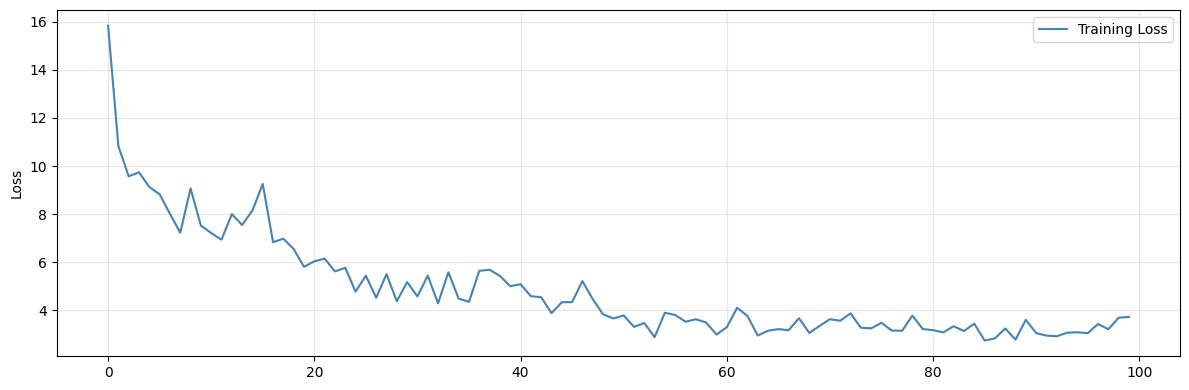

In [11]:
if hasattr(darwin_model, 'loss_history'):
    _, ax = plt.subplots(figsize=(12, 4))

    ax.plot(
        darwin_model.loss_history,
        label='Training Loss',
        color='steelblue',
        linewidth=1.5,
    )
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('')
    ax.set_ylabel('Loss')
    ax.legend(loc='best')

    plt.tight_layout()